Abby's Section!

In [1]:
import pandas as pd

import os
my_dir = os.path.expanduser('~/eeb125-20261/Untitled Folder')
os.chdir(my_dir)
print(os.getcwd())

#reading in the csv files 
IUCN_animals = pd.read_csv("IUCN_animals.csv")
GBIF_east_africa = pd.read_csv("GBIF_east_africa.csv", sep="\t")

IUCN_animals.head()

/home/jovyan/eeb125-20261/Untitled Folder


,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,infraType,infraName,infraAuthority,authority,redlistCategory,redlistCriteria,criteriaVersion,populationTrend,scopes
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,NaN,NaN,NaN,"(Bonnaterre, 1788)",Near Threatened,A2bd,3.1,Decreasing,Global
1,495907,10041,Heosemys annandalii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,GEOEMYDIDAE,Heosemys,annandalii,NaN,NaN,NaN,"(Boulenger in Annandale &amp; Robinson, 1903)",Critically Endangered,A2cd+4cd,3.1,Decreasing,Global
2,497499,132523146,Hubbsina turneri,ANIMALIA,CHORDATA,CYPRINODONTIFORMES,ACTINOPTERYGII,GOODEIDAE,Hubbsina,turneri,NaN,NaN,NaN,"(de Buen, 1940)",Critically Endangered,"B1ab(i,ii,iii,iv)+2ab(i,ii,iii,iv)",3.1,Decreasing,Global
3,497550,10267,Hungerfordia pelewensis,ANIMALIA,MOLLUSCA,ARCHITAENIOGLOSSA,GASTROPODA,DIPLOMMATINIDAE,Hungerfordia,pelewensis,NaN,NaN,NaN,"Beddome, 1889",Endangered,"B1ab(ii,iii)+2ab(ii,iii)",3.1,Unknown,Global
4,498370,10767,Ictalurus australis,ANIMALIA,CHORDATA,SILURIFORMES,ACTINOPTERYGII,ICTALURIDAE,Ictalurus,australis,NaN,NaN,NaN,"(Meek, 1904)",Data Deficient,NaN,3.1,Decreasing,Global


In [2]:
GBIF_east_africa.head()

,taxonKey,scientificName,acceptedTaxonKey,acceptedScientificName,numberOfOccurrences,taxonRank,taxonomicStatus,kingdom,kingdomKey,phylum,...,classKey,order,orderKey,family,familyKey,genus,genusKey,species,speciesKey,iucnRedListCategory
0,341,Turbellaria,341.0,Turbellaria,297,CLASS,ACCEPTED,Animalia,1,Platyhelminthes,...,341.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2390,Scrophulariaceae,2390.0,Scrophulariaceae,86,FAMILY,ACCEPTED,Plantae,6,Tracheophyta,...,220.0,Lamiales,408.0,Scrophulariaceae,2390.0,NaN,NaN,NaN,NaN,NE
2,4334,Apidae,4334.0,Apidae,39,FAMILY,ACCEPTED,Animalia,1,Arthropoda,...,216.0,Hymenoptera,1457.0,Apidae,4334.0,NaN,NaN,NaN,NaN,NE
3,1033975,"Enochrus Thomson, 1859",1033975.0,"Enochrus Thomson, 1859",47,GENUS,ACCEPTED,Animalia,1,Arthropoda,...,216.0,Coleoptera,1470.0,Hydrophilidae,7830.0,Enochrus,1033975.0,NaN,NaN,NaN
4,1055329,"Ablaberoides emeritus Péringuey, 1904",1055329.0,"Ablaberoides emeritus Péringuey, 1904",6,SPECIES,ACCEPTED,Animalia,1,Arthropoda,...,216.0,Coleoptera,1470.0,Melolonthidae,5593.0,Ablaberoides,1055303.0,Ablaberoides emeritus,1055329.0,NE


In [3]:
#Next we want to work with cleaned dataframes and only use relevant columnns to our research questions 


IUCN_cols = ['genusName','speciesName','scientificName','redlistCategory']

GBIF_cols = ['genus', 'species','iucnRedListCategory', 'numberOfOccurrences']

IUCN_filtered = IUCN_animals[IUCN_cols]

GBIF_filtered_EAf = GBIF_east_africa[GBIF_cols]

#the scientific name columns do not match between the datasets so let's correct that 

old_to_new_IUCN = {'genusName':'Genus',
                  'speciesName':'Species',
                  'scientificName':'Scientific Name',
                  'redlistCategory':'IUCN Red List Category'}

old_to_new_GBIF = {'genus':'Genus',
                  'species':'Scientific Name',
                  'iucnRedListCategory':'IUCN Red List Abbreviation', 
                  'numberOfOccurrences': 'Number of Occurrences'}

GBIF_renamed_EAf = GBIF_filtered_EAf.rename(columns = old_to_new_GBIF)

IUCN_renamed = IUCN_filtered.rename(columns = old_to_new_IUCN)

In [4]:
#converting data types 

GBIF_converted_EAf = GBIF_renamed_EAf.convert_dtypes()
IUCN_converted = IUCN_renamed.convert_dtypes()

In [5]:
#replacing the NaN values 
GBIF_converted_EAf = GBIF_converted_EAf.replace('NaN', pd.NA)
IUCN_converted = IUCN_converted.replace('NaN',pd.NA)

In [6]:
#merging the GBIF and IUCN datasets 

Africa_IUCN = pd.merge(
    left = GBIF_converted_EAf, 
    right = IUCN_converted, 
    left_on = "Scientific Name", 
    right_on = "Scientific Name")

Africa_IUCN

,Genus_x,Scientific Name,IUCN Red List Abbreviation,Number of Occurrences,Genus_y,Species,IUCN Red List Category
0,Hetrodes,Hetrodes pupus,LC,13,Hetrodes,pupus,Least Concern
1,Chrysichthys,Chrysichthys brachynema,LC,18,Chrysichthys,brachynema,Least Concern
2,Mastacembelus,Mastacembelus frenatus,LC,3,Mastacembelus,frenatus,Least Concern
3,Brycinus,Brycinus rhodopleura,NE,1,Brycinus,rhodopleura,Least Concern
4,Istigobius,Istigobius decoratus,LC,8,Istigobius,decoratus,Least Concern
...,...,...,...,...,...,...,...
10740,Motacilla,Motacilla flava,<NA>,1,Motacilla,flava,Least Concern
10741,Oenanthe,Oenanthe scotocerca,<NA>,4,Oenanthe,scotocerca,Least Concern
10742,Conus,Conus lividus,LC,49,Conus,lividus,Least Concern
10743,Crocidura,Crocidura macmillani,<NA>,1,Crocidura,macmillani,Near Threatened


Bonnie's Section!

In [7]:
GBIF_can_us  = pd.read_csv('GBIF_can_us.csv', sep='\t')

In [8]:
GBIF_filtered_can = GBIF_can_us[GBIF_cols]
GBIF_renamed_can = GBIF_filtered_can.rename(columns = old_to_new_GBIF)
GBIF_converted_can = GBIF_renamed_can.convert_dtypes()
GBIF_converted_can = GBIF_converted_can.replace('NaN', pd.NA)

In [9]:
#merging the GBIF and IUCN datasets 

North_America_IUCN = pd.merge(
    left = GBIF_converted_can, 
    right = IUCN_converted, 
    left_on = "Scientific Name", 
    right_on = "Scientific Name")

North_America_IUCN

,Genus_x,Scientific Name,IUCN Red List Abbreviation,Number of Occurrences,Genus_y,Species,IUCN Red List Category
0,Bombus,Bombus bifarius,LC,29667,Bombus,bifarius,Least Concern
1,Libellula,Libellula flavida,NE,1,Libellula,flavida,Least Concern
2,Sympetrum,Sympetrum semicinctum,NE,167,Sympetrum,semicinctum,Least Concern
3,Erythemis,Erythemis peruviana,LC,4,Erythemis,peruviana,Least Concern
4,Macrobrachium,Macrobrachium acanthurus,LC,57,Macrobrachium,acanthurus,Least Concern
...,...,...,...,...,...,...,...
21186,Nocomis,Nocomis micropogon,<NA>,1,Nocomis,micropogon,Least Concern
21187,Sporophila,Sporophila torqueola,<NA>,26,Sporophila,torqueola,Least Concern
21188,Helisoma,Helisoma anceps,<NA>,1,Helisoma,anceps,Least Concern
21189,Planorbella,Planorbella campanulata,<NA>,1,Planorbella,campanulata,Least Concern


Nathan's Section

In [10]:
GBIF_east_asia = pd.read_csv("GBIF_east_asia.csv", sep="\t")

In [11]:
GBIF_filtered_ea = GBIF_east_asia[GBIF_cols]
GBIF_renamed_ea = GBIF_filtered_ea.rename(columns = old_to_new_GBIF)
GBIF_converted_ea = GBIF_renamed_ea.convert_dtypes()
GBIF_converted_ea = GBIF_converted_ea.replace('NaN', pd.NA)

In [12]:
#merging the GBIF and IUCN datasets 

East_Asia_IUCN = pd.merge(
    left = GBIF_converted_ea, 
    right = IUCN_converted, 
    left_on = "Scientific Name", 
    right_on = "Scientific Name")

East_Asia_IUCN

,Genus_x,Scientific Name,IUCN Red List Abbreviation,Number of Occurrences,Genus_y,Species,IUCN Red List Category
0,Heliocypha,Heliocypha biforata,LC,2,Heliocypha,biforata,Least Concern
1,Lathrecista,Lathrecista asiatica,LC,2,Lathrecista,asiatica,Least Concern
2,Troides,Troides magellanus,LC,7,Troides,magellanus,Least Concern
3,Byasa,Byasa impediens,LC,27,Byasa,impediens,Least Concern
4,Euprymna,Euprymna berryi,DD,2,Euprymna,berryi,Data Deficient
...,...,...,...,...,...,...,...
11132,Rallus,Rallus aquaticus,<NA>,22,Rallus,aquaticus,Least Concern
11133,Geloina,Geloina luchuana,NE,1,Geloina,luchuana,Data Deficient
11134,Ardea,Ardea alba,<NA>,8,Ardea,alba,Least Concern
11135,Coilia,Coilia mystus,<NA>,3,Coilia,mystus,Endangered


Emily's Section

In [13]:
GBIF_south_america = pd.read_csv("GBIF_south_america_tropics.csv", sep="\t")

In [14]:
GBIF_filtered_sam = GBIF_south_america[GBIF_cols]
GBIF_renamed_sam = GBIF_filtered_sam.rename(columns = old_to_new_GBIF)
GBIF_converted_sam = GBIF_renamed_sam.convert_dtypes()
GBIF_converted_sam = GBIF_converted_sam.replace('NaN', pd.NA)

In [15]:
#merging the GBIF and IUCN datasets 

South_America_IUCN = pd.merge(
    left = GBIF_converted_sam, 
    right = IUCN_converted, 
    left_on = "Scientific Name", 
    right_on = "Scientific Name")

South_America_IUCN

,Genus_x,Scientific Name,IUCN Red List Abbreviation,Number of Occurrences,Genus_y,Species,IUCN Red List Category
0,Polythore,Polythore picta,LC,4,Polythore,picta,Least Concern
1,Micrathyria,Micrathyria catenata,LC,47,Micrathyria,catenata,Least Concern
2,Erythemis,Erythemis peruviana,LC,456,Erythemis,peruviana,Least Concern
3,Macrobrachium,Macrobrachium acanthurus,LC,98,Macrobrachium,acanthurus,Least Concern
4,Isorineloricaria,Isorineloricaria spinosissima,LC,2,Isorineloricaria,spinosissima,Least Concern
...,...,...,...,...,...,...,...
22768,Boana,Boana ericae,DD,4,Boana,ericae,Data Deficient
22769,Parides,Parides vertumnus,<NA>,3,Parides,vertumnus,Least Concern
22770,Boana,Boana secedens,DD,4,Boana,secedens,Data Deficient
22771,Grallaria,Grallaria andicolus,LC,3,Grallaria,andicolus,Least Concern


Okay, so all four datasets have been cleaned and merged with IUCN data. Before calculating proportions and creating bar graphs, we need to remove all overlapping species within each dataset. This will create datasets which contain species only unique to their particular areas. 

LIST OF DATASETS:
Africa_IUCN
North_America_IUCN
East_Asia_IUCN
South_America_IUCN

In [16]:
#clean data to make sure they can be properly compared 
col = "Scientific Name"
for df in [Africa_IUCN, North_America_IUCN, East_Asia_IUCN, South_America_IUCN]:
    df[col] = df[col].str.lower().str.strip()

In [17]:
#simple booleans for each dataset -> make them unique! 
#the code basically asks is the species in this region? or this? 
#if its not in any, it adds it to the unique dataframe

africa_unique = Africa_IUCN[
    (~Africa_IUCN[col].isin(North_America_IUCN[col])) &
    (~Africa_IUCN[col].isin(East_Asia_IUCN[col])) &
    (~Africa_IUCN[col].isin(South_America_IUCN[col]))
]

na_unique = North_America_IUCN[
    (~North_America_IUCN[col].isin(Africa_IUCN[col])) &
    (~North_America_IUCN[col].isin(East_Asia_IUCN[col])) &
    (~North_America_IUCN[col].isin(South_America_IUCN[col]))
]

asia_unique = East_Asia_IUCN[
    (~East_Asia_IUCN[col].isin(Africa_IUCN[col])) &
    (~East_Asia_IUCN[col].isin(North_America_IUCN[col])) &
    (~East_Asia_IUCN[col].isin(South_America_IUCN[col]))
]

sa_unique = South_America_IUCN[
    (~South_America_IUCN[col].isin(Africa_IUCN[col])) &
    (~South_America_IUCN[col].isin(North_America_IUCN[col])) &
    (~South_America_IUCN[col].isin(East_Asia_IUCN[col]))
]

I confirmed that this cleaning worked by comparing the amount of rows in the unique set to the original set -> im sure we can do code to count the amount of rows and we prob should but i just ran the whole dataset and jupyter shows the amount of rows 

In [18]:
#make a dataset of the proportions of IUCN values that we want!

not_DD = africa_unique['IUCN Red List Abbreviation'] != 'DD'
not_NE = africa_unique['IUCN Red List Abbreviation'] != 'NE'
not_EW = africa_unique['IUCN Red List Abbreviation'] != 'EW'
not_EX = africa_unique['IUCN Red List Abbreviation'] != 'EX'
africa_filtered = africa_unique[not_DD & not_NE & not_EW & not_EX]

not_DD = na_unique['IUCN Red List Abbreviation'] != 'DD'
not_NE = na_unique['IUCN Red List Abbreviation'] != 'NE'
not_EW = na_unique['IUCN Red List Abbreviation'] != 'EW'
not_EX = na_unique['IUCN Red List Abbreviation'] != 'EX'
na_filtered = na_unique[not_DD & not_NE & not_EW & not_EX]

not_DD = asia_unique['IUCN Red List Abbreviation'] != 'DD'
not_NE = asia_unique['IUCN Red List Abbreviation'] != 'NE'
not_EW = asia_unique['IUCN Red List Abbreviation'] != 'EW'
not_EX = asia_unique['IUCN Red List Abbreviation'] != 'EX'
asia_filtered = asia_unique[not_DD & not_NE & not_EW & not_EX]

not_DD = sa_unique['IUCN Red List Abbreviation'] != 'DD'
not_NE = sa_unique['IUCN Red List Abbreviation'] != 'NE'
not_EW = sa_unique['IUCN Red List Abbreviation'] != 'EW'
not_EX = sa_unique['IUCN Red List Abbreviation'] != 'EX'
sa_filtered = sa_unique[not_DD & not_NE & not_EW & not_EX]


africa_counts = africa_filtered.groupby('IUCN Red List Abbreviation')['Scientific Name'].nunique()
africa_prop = africa_counts / africa_counts.sum()

na_counts = na_filtered.groupby('IUCN Red List Abbreviation')['Scientific Name'].nunique()
na_prop = na_counts / na_counts.sum()

asia_counts = asia_filtered.groupby('IUCN Red List Abbreviation')['Scientific Name'].nunique()
asia_prop = asia_counts / asia_counts.sum()

sa_counts = sa_filtered.groupby('IUCN Red List Abbreviation')['Scientific Name'].nunique()
sa_prop = sa_counts / sa_counts.sum()

#now to put everything into a dataset so we can visualize!
IUCN_prop = pd.DataFrame({
    "Africa": africa_prop,
    "North America": na_prop,
    "South America": sa_prop,
    "Asia": asia_prop
})

IUCN_prop

,Africa,North America,South America,Asia
IUCN Red List Abbreviation,,,,
CR,0.026711,0.049777,0.031532,0.016570
EN,0.041975,0.068496,0.064604,0.044450
LC,0.839494,0.711763,0.761024,0.814834
NT,0.038397,0.067858,0.063774,0.054182
VU,0.053422,0.102106,0.079066,0.069963


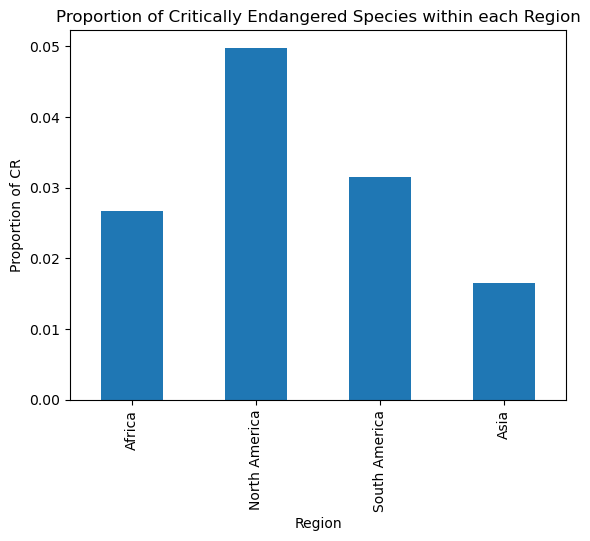

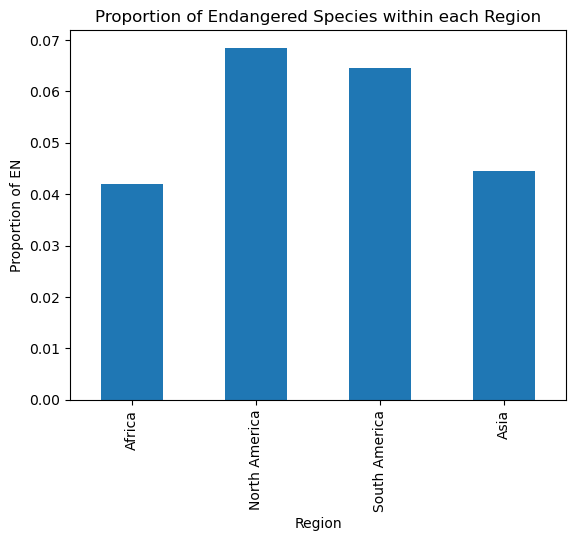

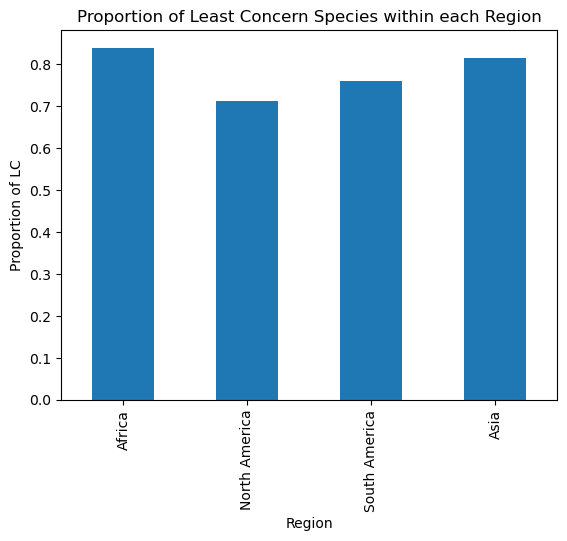

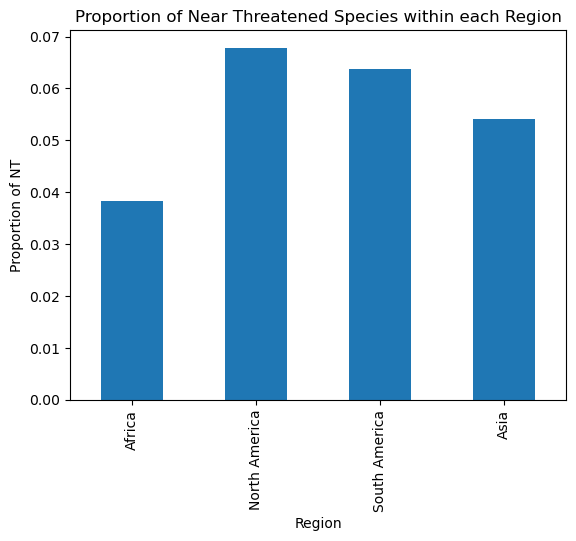

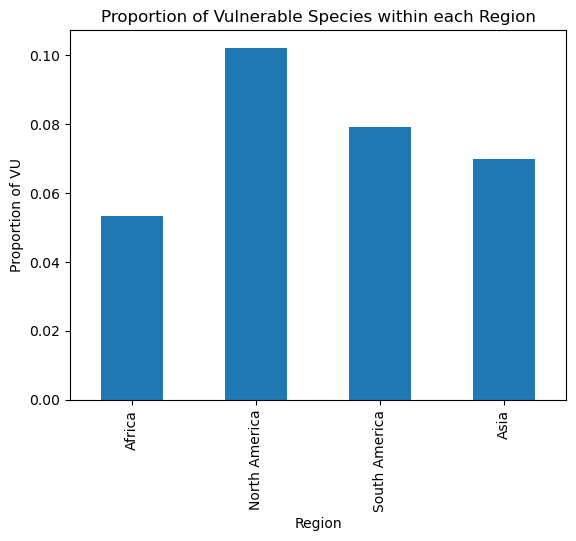

In [19]:
import matplotlib.pyplot as plt

cr_values = IUCN_prop.loc["CR"]
cr_values.plot(kind="bar")
plt.ylabel("Proportion of CR")
plt.xlabel("Region")
plt.title("Proportion of Critically Endangered Species within each Region")
plt.show()

en_values = IUCN_prop.loc["EN"]
en_values.plot(kind="bar")
plt.ylabel("Proportion of EN")
plt.xlabel("Region")
plt.title("Proportion of Endangered Species within each Region")
plt.show()

lc_values = IUCN_prop.loc["LC"]
lc_values.plot(kind="bar")
plt.ylabel("Proportion of LC")
plt.xlabel("Region")
plt.title("Proportion of Least Concern Species within each Region")
plt.show()

nt_values = IUCN_prop.loc["NT"]
nt_values.plot(kind="bar")
plt.ylabel("Proportion of NT")
plt.xlabel("Region")
plt.title("Proportion of Near Threatened Species within each Region")
plt.show()

vu_values = IUCN_prop.loc["VU"]
vu_values.plot(kind="bar")
plt.ylabel("Proportion of VU")
plt.xlabel("Region")
plt.title("Proportion of Vulnerable Species within each Region")
plt.show()

not sure if we will want to use all of these plots bc not all of them are super interesting. may want to do some test something to see if the differences between these values are statistically significant but comparing proportions is only one value so who knows if this is a good thing 

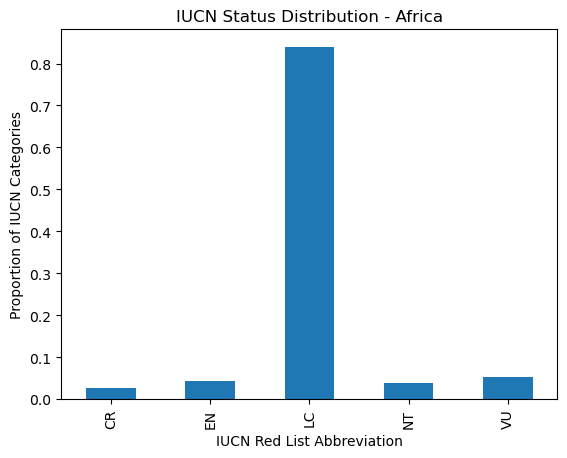

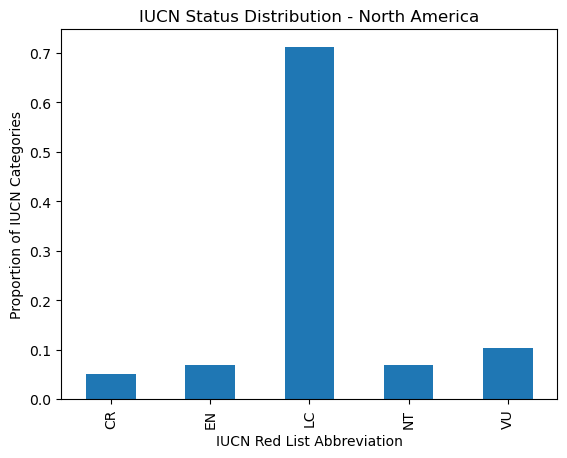

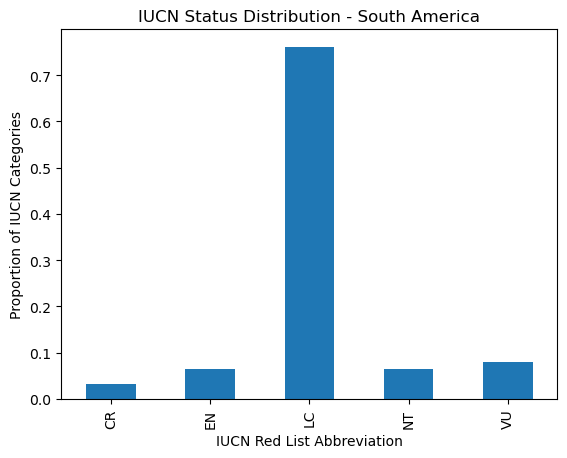

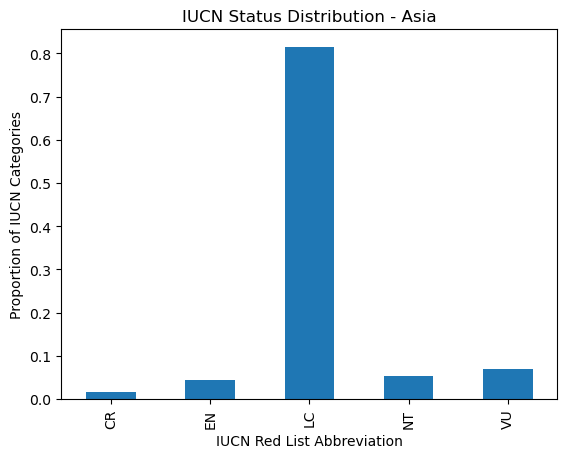

In [26]:
IUCN_prop["Africa"].plot(kind="bar")
plt.ylabel("Proportion of IUCN Categories")
plt.title("IUCN Status Distribution - Africa")
plt.show()

IUCN_prop["North America"].plot(kind="bar")
plt.ylabel("Proportion of IUCN Categories")
plt.title("IUCN Status Distribution - North America")
plt.show()

IUCN_prop["South America"].plot(kind="bar")
plt.ylabel("Proportion of IUCN Categories")
plt.title("IUCN Status Distribution - South America")
plt.show()

IUCN_prop["Asia"].plot(kind="bar")
plt.ylabel("Proportion of IUCN Categories")
plt.title("IUCN Status Distribution - Asia")
plt.show()

In [21]:
#run a chi-square tests
table_cr = pd.DataFrame({
    "Africa": [
        (africa_filtered["IUCN Red List Abbreviation"] == "CR").sum(),
        (africa_filtered["IUCN Red List Abbreviation"] != "CR").sum()
    ],
    "North America": [
        (na_filtered["IUCN Red List Abbreviation"] == "CR").sum(),
        (na_filtered["IUCN Red List Abbreviation"] != "CR").sum()
    ],
    "South America": [
        (sa_filtered["IUCN Red List Abbreviation"] == "CR").sum(),
        (sa_filtered["IUCN Red List Abbreviation"] != "CR").sum()
    ],
    "Asia": [
        (asia_filtered["IUCN Red List Abbreviation"] == "CR").sum(),
        (asia_filtered["IUCN Red List Abbreviation"] != "CR").sum()
    ]
})

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table_cr)

print("CR p-value:", p)

CR p-value: 1.3024907307912108e-20


In [22]:
table_vu = pd.DataFrame({
    "Africa": [
        (africa_filtered["IUCN Red List Abbreviation"] == "VU").sum(),
        (africa_filtered["IUCN Red List Abbreviation"] != "VU").sum()
    ],
    "North America": [
        (na_filtered["IUCN Red List Abbreviation"] == "VU").sum(),
        (na_filtered["IUCN Red List Abbreviation"] != "VU").sum()
    ],
    "South America": [
        (sa_filtered["IUCN Red List Abbreviation"] == "VU").sum(),
        (sa_filtered["IUCN Red List Abbreviation"] != "VU").sum()
    ],
    "Asia": [
        (asia_filtered["IUCN Red List Abbreviation"] == "VU").sum(),
        (asia_filtered["IUCN Red List Abbreviation"] != "VU").sum()
    ]
})

chi2, p_vu, dof, expected = chi2_contingency(table_vu)
print("VU p-value:", p_vu)

VU p-value: 2.7658131156587274e-20


In [23]:
table_en = pd.DataFrame({
    "Africa": [
        (africa_filtered["IUCN Red List Abbreviation"] == "EN").sum(),
        (africa_filtered["IUCN Red List Abbreviation"] != "EN").sum()
    ],
    "North America": [
        (na_filtered["IUCN Red List Abbreviation"] == "EN").sum(),
        (na_filtered["IUCN Red List Abbreviation"] != "EN").sum()
    ],
    "South America": [
        (sa_filtered["IUCN Red List Abbreviation"] == "EN").sum(),
        (sa_filtered["IUCN Red List Abbreviation"] != "EN").sum()
    ],
    "Asia": [
        (asia_filtered["IUCN Red List Abbreviation"] == "EN").sum(),
        (asia_filtered["IUCN Red List Abbreviation"] != "EN").sum()
    ]
})

chi2, p_en, dof, expected = chi2_contingency(table_en)
print("EN p-value:", p_en)

EN p-value: 2.3489791886257137e-14


In [24]:
table_lc = pd.DataFrame({
    "Africa": [
        (africa_filtered["IUCN Red List Abbreviation"] == "LC").sum(),
        (africa_filtered["IUCN Red List Abbreviation"] != "LC").sum()
    ],
    "North America": [
        (na_filtered["IUCN Red List Abbreviation"] == "LC").sum(),
        (na_filtered["IUCN Red List Abbreviation"] != "LC").sum()
    ],
    "South America": [
        (sa_filtered["IUCN Red List Abbreviation"] == "LC").sum(),
        (sa_filtered["IUCN Red List Abbreviation"] != "LC").sum()
    ],
    "Asia": [
        (asia_filtered["IUCN Red List Abbreviation"] == "LC").sum(),
        (asia_filtered["IUCN Red List Abbreviation"] != "LC").sum()
    ]
})

chi2, p_lc, dof, expected = chi2_contingency(table_lc)
print("LC p-value:", p_lc)

LC p-value: 1.3475274929016005e-67


In [25]:
table_nt = pd.DataFrame({
    "Africa": [
        (africa_filtered["IUCN Red List Abbreviation"] == "NT").sum(),
        (africa_filtered["IUCN Red List Abbreviation"] != "NT").sum()
    ],
    "North America": [
        (na_filtered["IUCN Red List Abbreviation"] == "NT").sum(),
        (na_filtered["IUCN Red List Abbreviation"] != "NT").sum()
    ],
    "South America": [
        (sa_filtered["IUCN Red List Abbreviation"] == "NT").sum(),
        (sa_filtered["IUCN Red List Abbreviation"] != "NT").sum()
    ],
    "Asia": [
        (asia_filtered["IUCN Red List Abbreviation"] == "NT").sum(),
        (asia_filtered["IUCN Red List Abbreviation"] != "NT").sum()
    ]
})

chi2, p_nt, dof, expected = chi2_contingency(table_nt)
print("NT p-value:", p_nt)

NT p-value: 1.2110679327425301e-11


ok so. we couldnt do anova or linear regression to do statistical analyses on our data. i did chi square tests which are fine ig but all of them show that there is significant difference in the proportions of the species distribution across the regions. im not 1000% sure if this makes sense so im not sure if we want to include any of that, plus we didnt learn chi square in this course regardless. 

either way, the chi square test results arent super exciting because it doesnt tell us WHY the proportion is different (ex. Africa has a high CR value), it just indicates that the proportions are different across all regions. definitely some decisions to make abt what we want to show in the presentation because we wont have much time. 